In [2]:
# ================================================================================
#                               MEDICAL ANALYASYS
# ================================================================================

In [3]:
# ---------------------------------------------
#    Exploratory Data Analysis(EDA)
# ---------------------------------------------

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv(r"C:\ProgramData\MySQL\MySQL Server 8.0\Uploads\cleaned_diabaties_table.csv")

In [6]:
# ``````````````````````````````````````````````
#          UNIVARITATE ANALYSIS
# ``````````````````````````````````````````````

In [7]:
# Age distribution
df.groupby("age")["age"].count().reset_index(name="total_patients").sort_values(by="total_patients",ascending=False)


,age,total_patients
6,70-80,26068
5,60-70,22483
4,50-60,17256
7,80-90,17197
3,40-50,9685
2,30-40,3775
8,90-100,2793
1,20-30,1657
9,Unknown,691
0,0-10,161


In [8]:
# Readmission distribution
df.groupby("readmitted")["readmitted"].count().reset_index(name="total_patients").sort_values(by="total_patients", ascending=False)

,readmitted,total_patients
2,NO,54864
1,>30,35545
0,<30,11357


In [9]:
#Gender Distribution
df.groupby("gender")["gender"].count().reset_index(name="total_count").sort_values(by="total_count", ascending=False)

,gender,total_count
0,Female,54711
1,Male,47055


In [10]:
# Diagnosis category distribution
df.groupby('diag_1_category')["diag_1_category"].count().reset_index(name="total_patients").sort_values(by="total_patients",ascending=False)

,diag_1_category,total_patients
1,Circulatory,30336
4,Endocrine/Metabolic,11459
14,Respiratory,10407
3,Digestive,9208
17,Symptoms,7636
8,Injury/Poisoning,6974
6,Genitourinary,5078
10,Musculoskeletal,4957
11,Neoplasms,3433
7,Infectious Diseases,2768


In [11]:
# ``````````````````````````````````````````````
#          BIVARITATE ANALYSIS
# ``````````````````````````````````````````````

In [15]:
# Age vs readmission
df.groupby(["age", "readmitted"]) \
    .size() \
    .reset_index(name="total_count") \
    .sort_values(by="age")

,age,readmitted,total_count
0,0-10,<30,3
1,0-10,>30,26
2,0-10,NO,132
3,20-30,<30,236
4,20-30,>30,510
5,20-30,NO,911
6,30-40,<30,424
7,30-40,>30,1187
8,30-40,NO,2164
9,40-50,<30,1027


In [ ]:
#Insulin vs readmission
df.groupby(["insulin", "readmitted"]) \
  .size() \
  .reset_index(name="total_patients") \
  .sort_values(by="total_patients", ascending=False)

,insulin,readmitted,total_patients
5,No,NO,26678
8,Steady,NO,16934
4,No,>30,15949
7,Steady,>30,10482
2,Down,NO,5768
11,Up,NO,5484
3,No,<30,4756
1,Down,>30,4752
10,Up,>30,4362
6,Steady,<30,3433


In [ ]:
# Diagnosis vs readmission
df.groupby(["diag_1_category", "readmitted"]) \
  .size() \
  .reset_index(name="total_patients") \
  .sort_values(by="total_patients",ascending=False)

,diag_1_category,readmitted,total_patients
5,Circulatory,NO,16046
4,Circulatory,>30,10816
14,Endocrine/Metabolic,NO,5772
42,Respiratory,NO,5181
11,Digestive,NO,4979
51,Symptoms,NO,4229
13,Endocrine/Metabolic,>30,4222
41,Respiratory,>30,4114
24,Injury/Poisoning,NO,3883
3,Circulatory,<30,3474


In [ ]:
df.columns


Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'insulin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted', 'diag_1_category', 'diag_2_category',
       'diag_3_category'],
      dtype='object')

In [23]:
# Specialty vs readmission
df.groupby(["medical_specialty", "readmitted"]) \
  .size() \
  .reset_index(name="total_patients") \
  .sort_values(by="total_patients",ascending=False).head(10)

,medical_specialty,readmitted,total_patients
86,Unknown,NO,25952
85,Unknown,>30,18216
20,InternalMedicine,NO,8266
84,Unknown,<30,5781
19,InternalMedicine,>30,4723
11,Family/GeneralPractice,NO,3894
5,Emergency/Trauma,NO,3713
2,Cardiology,NO,3074
4,Emergency/Trauma,>30,3006
10,Family/GeneralPractice,>30,2663


In [ ]:
# ``````````````````````````````````````````````
#          CORRELATION ANALYSIS
# ``````````````````````````````````````````````

In [24]:
numerical_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

In [29]:
corr_matrix = df[numerical_cols].corr()

corr_matrix

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.000000,0.318450,0.191472,0.466135,-0.008916,-0.009681,0.073623,0.220186
num_lab_procedures,0.318450,1.000000,0.058066,0.268161,-0.007602,-0.002279,0.039231,0.152773
num_procedures,0.191472,0.058066,1.000000,0.385767,-0.024819,-0.038179,-0.066236,0.073734
num_medications,0.466135,0.268161,0.385767,1.000000,0.045197,0.013180,0.064194,0.261526
number_outpatient,-0.008916,-0.007602,-0.024819,0.045197,1.000000,0.091459,0.107338,0.094152
number_emergency,-0.009681,-0.002279,-0.038179,0.013180,0.091459,1.000000,0.266559,0.055539
number_inpatient,0.073623,0.039231,-0.066236,0.064194,0.107338,0.266559,1.000000,0.104710
number_diagnoses,0.220186,0.152773,0.073734,0.261526,0.094152,0.055539,0.104710,1.000000


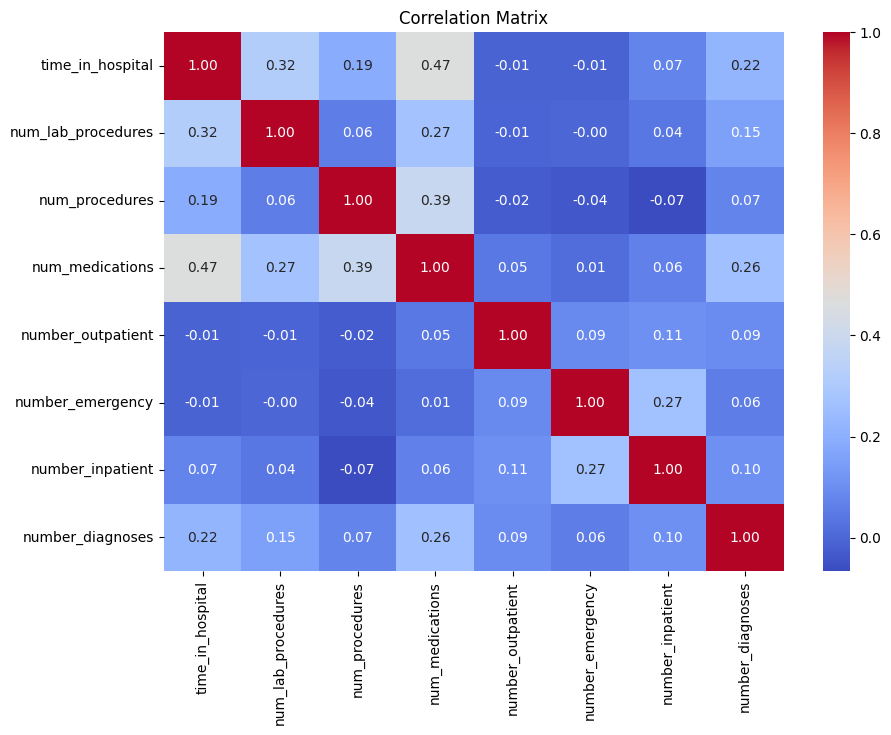

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()